In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Ready for Project 2!")

Ready for Project 2!


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500
df = pd.DataFrame({
    'CustomerID': range(1, n+1),
    'Age': np.random.randint(18, 70, n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Annual_Income': np.random.randint(20000, 150000, n),
    'Spending_Score': np.random.randint(1, 100, n),
    'Purchase_Frequency': np.random.randint(1, 50, n),
    'Total_Purchases': np.random.randint(100, 10000, n),
})

df.to_csv('customer_data.csv', index=False)
print("Dataset created!")
print("Shape:", df.shape)
print(df.head())

Dataset created!
Shape: (500, 7)
   CustomerID  Age  Gender  Annual_Income  Spending_Score  Purchase_Frequency  \
0           1   56  Female         142418               7                  28   
1           2   69    Male          63088              82                  33   
2           3   46    Male         136868              91                  48   
3           4   32  Female         123196              34                  41   
4           5   60    Male          59811              91                  13   

   Total_Purchases  
0             1767  
1             9929  
2             4214  
3             3653  
4             7861  


In [3]:
df = pd.read_csv('customer_data.csv')

# Check missing values
print("Missing values:\n", df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Missing values:
 CustomerID            0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
Total_Purchases       0
dtype: int64

Basic Statistics:
       CustomerID         Age  Annual_Income  Spending_Score  \
count  500.000000  500.000000     500.000000      500.000000   
mean   250.500000   44.220000   85301.972000       50.862000   
std    144.481833   15.036082   40057.959655       29.125101   
min      1.000000   18.000000   20055.000000        1.000000   
25%    125.750000   32.000000   47585.500000       25.750000   
50%    250.500000   45.000000   87694.500000       51.000000   
75%    375.250000   57.000000  121749.250000       77.000000   
max    500.000000   69.000000  149922.000000       99.000000   

       Purchase_Frequency  Total_Purchases  
count          500.000000       500.000000  
mean            25.122000      5354.254000  
std             13.975039      2868.476015  
min              1.000000 

In [4]:
print("=== RFM ANALYSIS ===")
print(f"Average Purchase Frequency : {df['Purchase_Frequency'].mean():.2f}")
print(f"Average Spending Score     : {df['Spending_Score'].mean():.2f}")
print(f"Average Annual Income      : Rs.{df['Annual_Income'].mean():,.2f}")
print(f"Average Total Purchases    : Rs.{df['Total_Purchases'].mean():,.2f}")

=== RFM ANALYSIS ===
Average Purchase Frequency : 25.12
Average Spending Score     : 50.86
Average Annual Income      : Rs.85,301.97
Average Total Purchases    : Rs.5,354.25


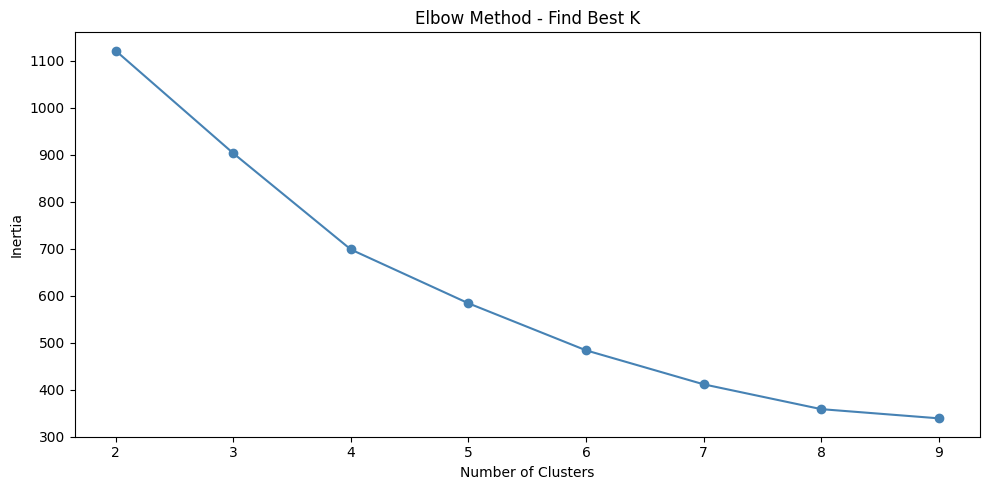

Elbow chart saved!


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale features
features = ['Annual_Income', 'Spending_Score', 'Purchase_Frequency']
scaler = StandardScaler()
scaled = scaler.fit_transform(df[features])

# Elbow method
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 10), inertia, marker='o', color='steelblue')
plt.title('Elbow Method - Find Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('elbow.png')
plt.show()
print("Elbow chart saved!")

In [6]:
km = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = km.fit_predict(scaled)

print("Cluster counts:")
print(df['Cluster'].value_counts())

Cluster counts:
Cluster
2    141
3    124
1    121
0    114
Name: count, dtype: int64


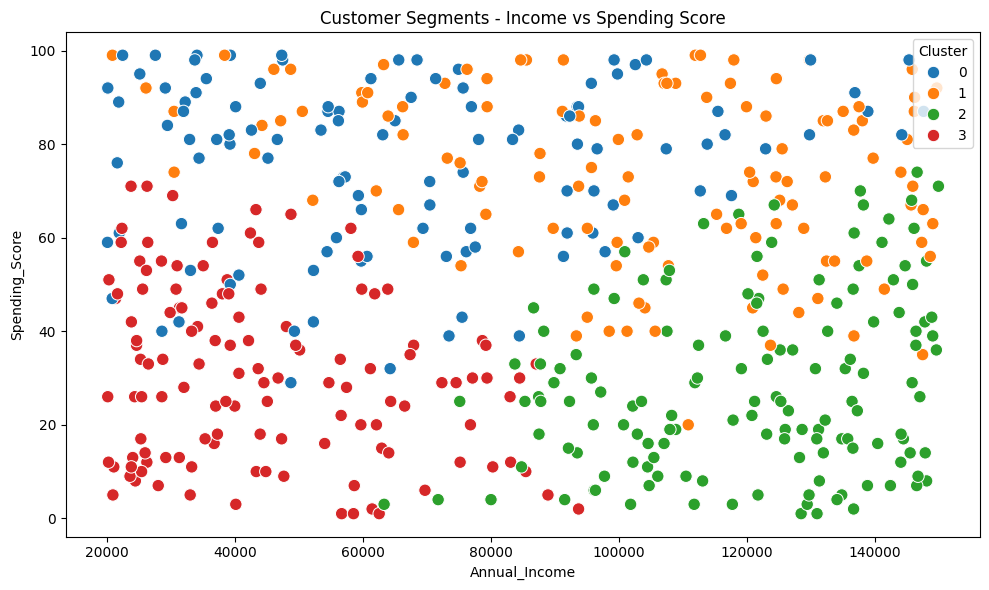

Cluster chart saved!


In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='Cluster', palette='tab10', s=80)
plt.title('Customer Segments - Income vs Spending Score')
plt.tight_layout()
plt.savefig('clusters.png')
plt.show()
print("Cluster chart saved!")

=== CLUSTER SUMMARY ===
         Annual_Income  Spending_Score  Purchase_Frequency
Cluster                                                   
0             67433.84           76.17               37.50
1            102814.50           73.56               12.81
2            120266.35           28.55               30.25
3             44882.40           30.82               19.93


<Figure size 1000x500 with 0 Axes>

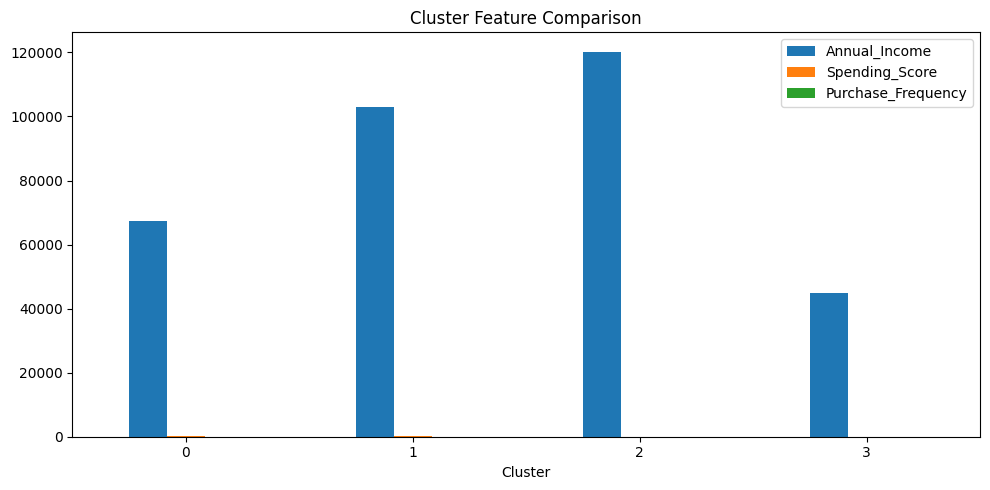

Chart saved!


In [8]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print("=== CLUSTER SUMMARY ===")
print(cluster_summary)

plt.figure(figsize=(10, 5))
cluster_summary.plot(kind='bar', figsize=(10, 5))
plt.title('Cluster Feature Comparison')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cluster_comparison.png')
plt.show()
print("Chart saved!")

<Figure size 1000x500 with 0 Axes>

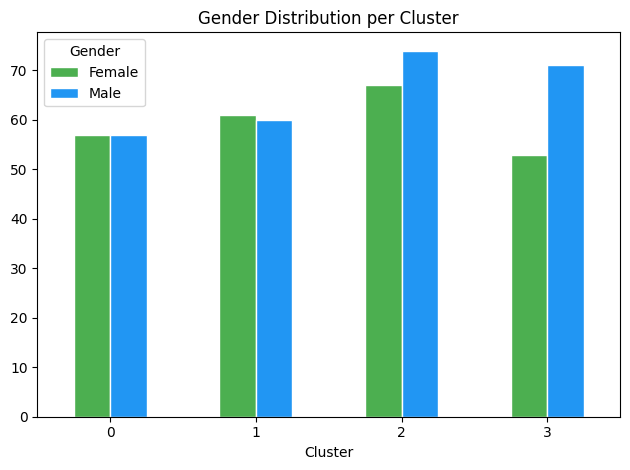

Chart saved!


In [9]:
plt.figure(figsize=(10, 5))
pd.crosstab(df['Cluster'], df['Gender']).plot(kind='bar',
            color=['#4CAF50','#2196F3'], edgecolor='white')
plt.title('Gender Distribution per Cluster')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_cluster.png')
plt.show()
print("Chart saved!")

In [10]:
print("========== PROJECT 2 SUMMARY ==========")
print(f"Total Customers   : {len(df)}")
print(f"Total Clusters    : 4")
print()
print("Cluster Descriptions:")
print("Cluster 0 — Low Income,  Low Spending  → Budget Customers")
print("Cluster 1 — High Income, High Spending → Premium Customers")
print("Cluster 2 — Low Income,  High Spending → Impulsive Customers")
print("Cluster 3 — High Income, Low Spending  → Saving Customers")
print()
print("Charts saved: elbow, clusters, cluster_comparison, gender_cluster")
print("Project 2 Complete!")

========== PROJECT 2 SUMMARY ==========
Total Customers   : 500
Total Clusters    : 4

Cluster Descriptions:
Cluster 0 — Low Income,  Low Spending  → Budget Customers
Cluster 1 — High Income, High Spending → Premium Customers
Cluster 2 — Low Income,  High Spending → Impulsive Customers
Cluster 3 — High Income, Low Spending  → Saving Customers

Charts saved: elbow, clusters, cluster_comparison, gender_cluster
Project 2 Complete!


In [11]:
import os
print(os.getcwd())

C:\Users\JERIN\oasis_internship
